# Factorized Split SAE: Opening the Architecture

This notebook is an executable explanation of the factorized Split Sparse
Autoencoder (Split SAE). It inspects the architecture from four angles:

1. **Mechanism:** how `z_good` supplies content and `z_bad` selects a style
   transformation.
2. **Tensor flow:** what each internal representation contains and how its
   shape changes.
3. **Learned behavior:** style probabilities, transform matrices, forced
   style interventions, and reconstruction trajectories.
4. **Evidence:** training history, post-hoc probes, counterfactual results,
   and an explicit gradient-flow audit.

The default checkpoint is the current **no-style-label** experiment. It
has no style cross-entropy, no bad color-head objective, and no good color
adversary. This makes it a useful test of what the architecture,
canonicalization, paired invariance, and reconstruction losses learn
without direct red/green label supervision.

> The notebook is diagnostic, not a training script. Change `RUN_NAME`,
> `CHECKPOINT_NAME`, or `SPLIT` in the configuration cell to inspect
> another factorized run.

## 1. Why factorize the decoder?

The earlier additive model reconstructed a 64-dimensional base-AE
embedding as

$$
\hat h = D_{\mathrm{good}}(z_{\mathrm{good}})
       + D_{\mathrm{bad}}(z_{\mathrm{bad}}).
$$

Both branches could emit arbitrary 64-dimensional vectors. Even when
`z_bad` was small and strongly color-predictive, its decoder often needed
digit shape to create the color residual at the correct locations. The
architecture therefore did not enforce the intended semantic roles.

The factorized model instead uses

$$
c = D_{\mathrm{good}}(z_{\mathrm{good}}),
\qquad
\ell = S(z_{\mathrm{bad}}),
\qquad
\pi = \operatorname{softmax}(\ell/\tau),
$$

where $c$ is a canonical content embedding and $\pi$ is a mixture
over learned style transforms. For style $k$,

$$
T_k(c) = c + A_k c + b_k.
$$

The final reconstruction is

$$
\hat h
= \sum_k \pi_k T_k(c)
= c + \sum_k \pi_k(A_k c+b_k).
$$

In functional notation:

$$
\boxed{\hat h = T_{z_{\mathrm{bad}}}
\left(D_{\mathrm{good}}(z_{\mathrm{good}})\right)}
$$

`z_bad` no longer decodes an independent image-shaped residual. It
chooses how a content embedding should be transformed. Shape is supplied
to the style operation through $c$, so the selector can focus on style.

In [1]:
from pathlib import Path
import inspect
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/toy-sae-matplotlib")

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import Code, Markdown, display

# Locate the repository whether Jupyter starts in the repo root or notebooks/.
start = Path.cwd().resolve()
PROJECT_ROOT = next(
    path for path in [start, *start.parents]
    if (path / "src" / "toy_sae").exists()
)
SRC_ROOT = PROJECT_ROOT / "src"
for path in [PROJECT_ROOT, SRC_ROOT]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from scripts.debug.visualize_reconstructions import (
    COLOR_NAMES,
    image_from_array,
    image_from_tensor,
    load_base_autoencoder,
    load_embedding_split,
    load_image_split,
)
import scripts.train.train_split_sae_canonical_good as canonical_good
import scripts.train.train_split_sae_canonical_good_scheduled as scheduled
from toy_sae.models.factorized_split_sae import (
    FactorizedSplitSparseAutoencoder,
)
from toy_sae.utils.checkpoints import load_checkpoint
from toy_sae.utils.embeddings import load_scaler
from toy_sae.utils.split_sae_loading import (
    infer_model_family,
    load_split_sae_model,
)
from toy_sae.utils.torch_utils import get_device

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})

RUN_NAME = (
    "factorized_green_zbad4_sched_vpair_"
    "no_style_labels_p1_10_p2_30_seed0"
)
CHECKPOINT_NAME = "best_recon"
SPLIT = "test_balanced"
NUM_VISUAL_EXAMPLES = 6

RUN_DIR = (
    PROJECT_ROOT / "checkpoints" / "factorized_split_sae" / RUN_NAME
)
CHECKPOINT_PATH = RUN_DIR / f"{CHECKPOINT_NAME}.pt"
HISTORY_PATH = RUN_DIR / "history.json"
SCALER_PATH = RUN_DIR / "embedding_scaler.npz"
RESULT_TAG = f"{RUN_NAME}_{CHECKPOINT_NAME}"

assert CHECKPOINT_PATH.exists(), f"Missing {CHECKPOINT_PATH}"
print(f"Project root: {PROJECT_ROOT}")
print(f"Run:          {RUN_NAME}")
print(f"Checkpoint:   {CHECKPOINT_PATH.name}")

Project root: /Users/cuzdu/Desktop/toy-sae
Run:          factorized_green_zbad4_sched_vpair_no_style_labels_p1_10_p2_30_seed0
Checkpoint:   best_recon.pt


/Users/cuzdu/miniconda3/envs/toy-sae/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = get_device()
checkpoint = load_checkpoint(CHECKPOINT_PATH)
model_family = infer_model_family(checkpoint)
assert model_family == "factorized_style", model_family

model = load_split_sae_model(
    checkpoint,
    device,
    model_family="factorized_style",
)
args = checkpoint["args"]
history = json.loads(HISTORY_PATH.read_text())
mean, std = load_scaler(SCALER_PATH)

def project_path(value):
    path = Path(value)
    return path if path.is_absolute() else PROJECT_ROOT / path

embedding_dir = project_path(args["embedding_dir"])
image_dir = project_path(args["image_dir"])
base_checkpoint = project_path(args["base_ae_checkpoint"])
base_ae = load_base_autoencoder(base_checkpoint, device)

selected_args = [
    "input_dim", "hidden_dim", "good_latent_dim", "bad_latent_dim",
    "num_styles", "style_hidden_dim", "style_temperature",
    "canonical_good_target", "good_full_recon_grad_scale",
    "lambda_recon", "lambda_canonical_good", "lambda_pair",
    "lambda_badcon", "lambda_style_selection", "lambda_adv",
    "lambda_dom", "phase1_epochs", "phase2_epochs",
]
print(f"Device: {device}")
print(f"Checkpoint epoch: {checkpoint['epoch']}")
for name in selected_args:
    print(f"{name:32s} {args.get(name)}")

Device: mps
Checkpoint epoch: 100
input_dim                        64
hidden_dim                       128
good_latent_dim                  128
bad_latent_dim                   4
num_styles                       2
style_hidden_dim                 16
style_temperature                1.0
canonical_good_target            green
good_full_recon_grad_scale       0.25
lambda_recon                     1.0
lambda_canonical_good            1.0
lambda_pair                      0.5
lambda_badcon                    0.1
lambda_style_selection           0.0
lambda_adv                       0.0
lambda_dom                       0.0
phase1_epochs                    10
phase2_epochs                    30


## 2. Architecture map

The encoder still begins with a shared trunk. The factorization is on the
decoding side:

- `z_good -> good_decoder -> canonical content`
- `z_bad -> style_selector -> style probabilities`
- `canonical content + transform bank + style probabilities -> reconstruction`

This distinction matters. The architecture restricts what the
**decoder-facing style code** can do, but the shared encoder trunk still
receives gradients from both branches.

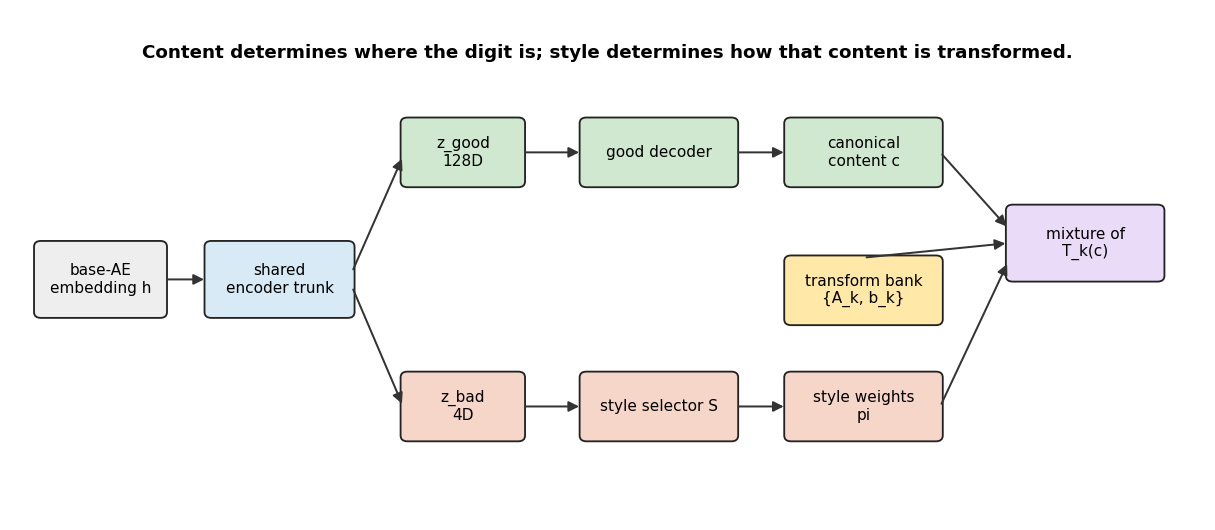

In [3]:
def architecture_diagram():
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 7)
    ax.axis("off")

    def box(x, y, w, h, text, color):
        patch = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.03,rounding_size=0.08",
            facecolor=color, edgecolor="#222222", linewidth=1.2,
        )
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center")
        return patch

    def arrow(x1, y1, x2, y2, label=None):
        ax.add_patch(FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="-|>", mutation_scale=14,
            linewidth=1.3, color="#333333",
        ))
        if label:
            ax.text(
                (x1 + x2) / 2, min(y1, y2) - 0.42,
                label, ha="center", fontsize=9,
            )

    box(0.3, 2.8, 1.5, 1.0, "base-AE\nembedding h", "#eeeeee")
    box(2.3, 2.8, 1.7, 1.0, "shared\nencoder trunk", "#d9eaf7")
    box(4.6, 4.6, 1.4, 0.9, "z_good\n128D", "#cfe8cf")
    box(4.6, 1.1, 1.4, 0.9, "z_bad\n4D", "#f6d6c9")
    box(6.7, 4.6, 1.8, 0.9, "good decoder", "#cfe8cf")
    box(9.1, 4.6, 1.8, 0.9, "canonical\ncontent c", "#cfe8cf")
    box(6.7, 1.1, 1.8, 0.9, "style selector S", "#f6d6c9")
    box(9.1, 1.1, 1.8, 0.9, "style weights\npi", "#f6d6c9")
    box(9.1, 2.7, 1.8, 0.9, "transform bank\n{A_k, b_k}", "#ffe8a8")
    box(11.7, 3.3, 1.8, 1.0, "mixture of\nT_k(c)", "#eadcf8")

    arrow(1.8, 3.3, 2.3, 3.3)
    arrow(4.0, 3.4, 4.6, 5.0)
    arrow(4.0, 3.2, 4.6, 1.55)
    arrow(6.0, 5.05, 6.7, 5.05)
    arrow(8.5, 5.05, 9.1, 5.05)
    arrow(6.0, 1.55, 6.7, 1.55)
    arrow(8.5, 1.55, 9.1, 1.55)
    arrow(10.9, 5.05, 11.7, 4.0)
    arrow(10.9, 1.55, 11.7, 3.55)
    arrow(10.0, 3.6, 11.7, 3.8)

    ax.text(
        7.0, 6.35,
        "Content determines where the digit is; style determines how "
        "that content is transformed.",
        ha="center", fontsize=12, weight="bold",
    )
    plt.show()

architecture_diagram()

### What changed relative to the additive model?

The encoder and good decoder remain conceptually similar. The critical
replacement is:

$$
D_{\mathrm{bad}}(z_{\mathrm{bad}}) \in \mathbb{R}^{64}
\quad\longrightarrow\quad
\pi(z_{\mathrm{bad}}) \in \Delta^{K-1}.
$$

The model still learns full $64\times64$ affine residual transforms,
but they are shared across examples. Per-example `z_bad` controls only
their mixture weights. This separates:

- information stored in raw `z_bad`;
- information retained by the style selector;
- information actually consumed by the decoder.

In [4]:
parameter_groups = {
    "shared encoder": model.encoder,
    "good encoder": model.good_encoder,
    "bad encoder": model.bad_encoder,
    "good decoder": model.good_decoder,
    "style selector": model.style_selector,
    "good color head": model.good_color_head,
    "bad color head": model.bad_color_head,
}

rows = []
for name, module in parameter_groups.items():
    count = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    rows.append((name, count, trainable))
rows.append((
    "style transform matrices",
    model.style_residual_matrices.numel(),
    model.style_residual_matrices.numel(),
))
rows.append((
    "style transform biases",
    model.style_residual_biases.numel(),
    model.style_residual_biases.numel(),
))

print(f"{'component':28s} {'parameters':>12s} {'trainable':>12s}")
print("-" * 56)
for name, count, trainable in rows:
    print(f"{name:28s} {count:12,d} {trainable:12,d}")
print("-" * 56)
print(f"{'whole model':28s} {sum(p.numel() for p in model.parameters()):12,d}")

display(Markdown("#### Actual `apply_style` implementation"))
display(Code(
    inspect.getsource(FactorizedSplitSparseAutoencoder.apply_style),
    language="python",
))

component                      parameters    trainable
--------------------------------------------------------
shared encoder                     24,832       24,832
good encoder                       16,512       16,512
bad encoder                           516          516
good decoder                       24,768       24,768
style selector                        114          114
good color head                    16,770       16,770
bad color head                        898          898
style transform matrices            8,192        8,192
style transform biases                128          128
--------------------------------------------------------
whole model                        92,730


#### Actual `apply_style` implementation

def apply_style(self, content, style_weights):
        """Apply a content-conditioned mixture of affine residual transforms."""
        style_residuals = torch.einsum(
            "bi,koi->bko",
            content,
            self.style_residual_matrices,
        )
        style_residuals = style_residuals + self.style_residual_biases.unsqueeze(0)
        mixed_residual = torch.einsum("bk,bki->bi", style_weights, style_residuals)
        return content + mixed_residual

## 3. Training objectives and gradient routing

The main losses are:

**Canonical content**

$$
\mathcal L_{\mathrm{canon}}
= \|D_{\mathrm{good}}(z_{\mathrm{good}})-h_{\mathrm{canon}}\|_2^2.
$$

**Variance-normalized paired invariance**

$$
\mathcal L_{\mathrm{pair}}
=
\frac{1}{d_g}\sum_j
\frac{(z^{(r)}_{\mathrm{good},j}
      -z^{(g)}_{\mathrm{good},j})^2}
     {\operatorname{Var}(z_{\mathrm{good},j})+\epsilon}.
$$

**Full reconstruction**

$$
\mathcal L_{\mathrm{recon}}=\|\hat h-h\|_2^2.
$$

**Style-contribution control**

$$
\mathcal L_{\mathrm{badcon}}
=\|\hat h-c\|_2^2.
$$

The full-reconstruction gradient into content is gated:

$$
c_{\mathrm{gate}}
=\alpha c+(1-\alpha)\operatorname{stopgrad}(c).
$$

Here $\alpha=0.25$. This weakens the colored reconstruction signal
entering the good decoder and good encoder. It does **not** isolate the
shared trunk: reconstruction can still update the trunk through
`z_bad -> style_selector`.

The default run uses:

$$
\lambda_{\mathrm{style\ CE}}
=\lambda_{\mathrm{adv}}
=\lambda_{\mathrm{dom}}=0.
$$

Color names are therefore not assigned to style indices during
training. The index-to-color mapping must be inferred after training.

## 4. Training history

Scheduled training has three conceptual periods:

1. **Good warm-up:** style is disabled; learn canonical content and
   paired invariance.
2. **Residual/style warm-up:** enable the style branch gently.
3. **Full objective:** retain content constraints while optimizing the
   complete factorized reconstruction.

The plots below expose reconstruction, canonicalization, pair
invariance, latent usage, style confidence, and scheduled weights.

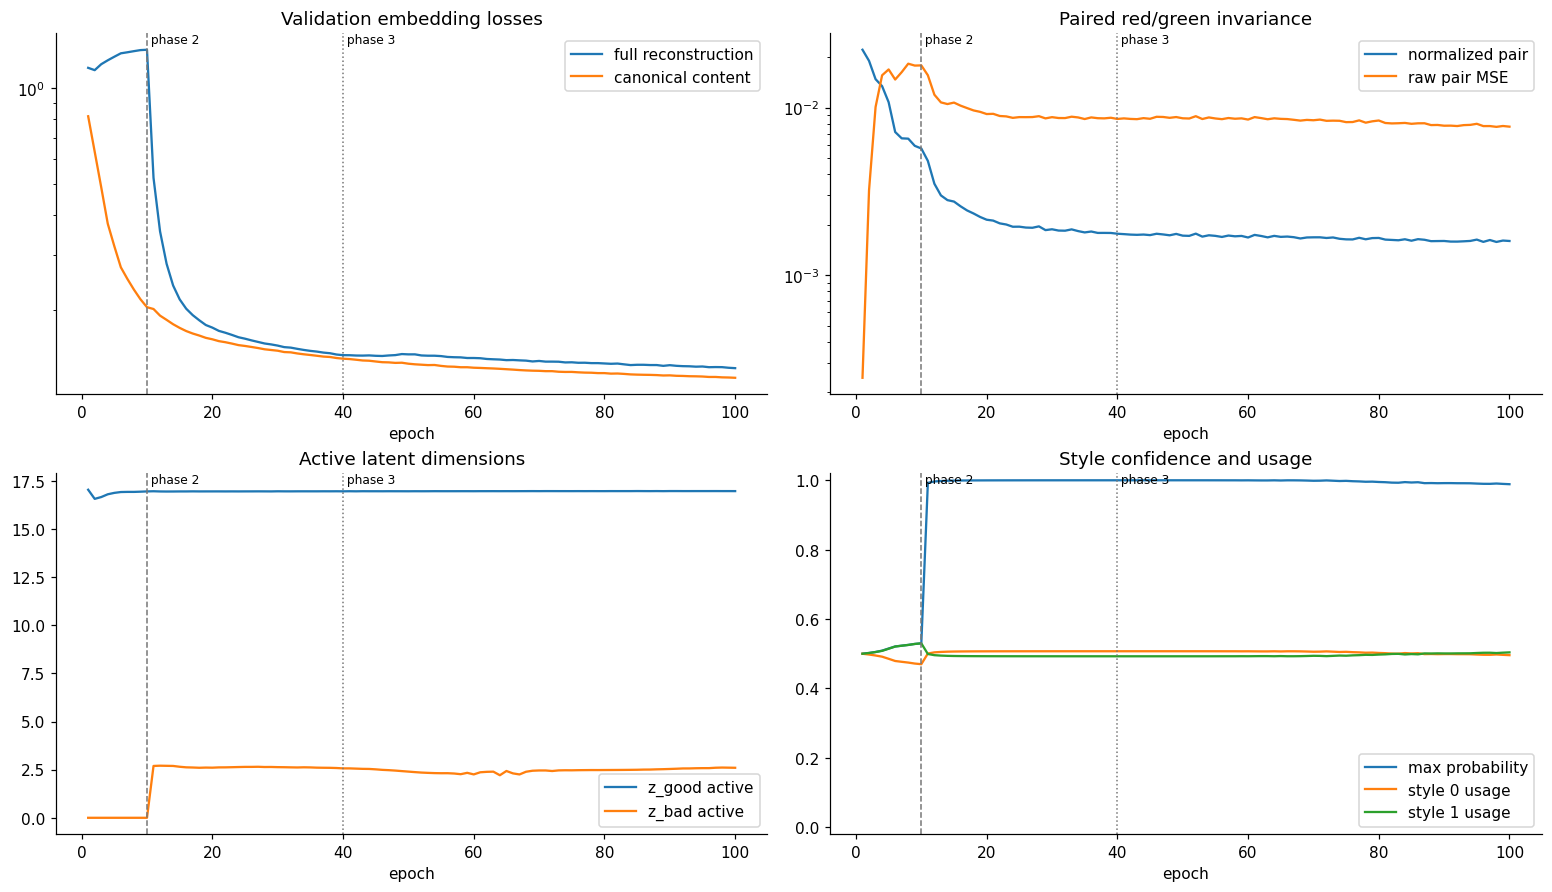

Final validation: recon=0.1316, canonical=0.1228, pair=0.00160, style_max=0.9887, usage=[0.496, 0.504]


In [5]:
epochs = np.array([entry["epoch"] for entry in history])

def series(section, key):
    return np.array([entry[section][key] for entry in history])

phase1_end = args["phase1_epochs"]
phase2_end = args["phase1_epochs"] + args["phase2_epochs"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

ax = axes[0, 0]
ax.plot(epochs, series("val", "recon_mse"), label="full reconstruction")
ax.plot(epochs, series("val", "canonical_good_mse"), label="canonical content")
ax.set_yscale("log")
ax.set_title("Validation embedding losses")
ax.set_xlabel("epoch")
ax.legend()

ax = axes[0, 1]
ax.plot(epochs, series("val", "good_pair_loss"), label="normalized pair")
ax.plot(epochs, series("val", "good_pair_mse"), label="raw pair MSE")
ax.set_yscale("log")
ax.set_title("Paired red/green invariance")
ax.set_xlabel("epoch")
ax.legend()

ax = axes[1, 0]
ax.plot(epochs, series("val", "z_good_active_count"), label="z_good active")
ax.plot(epochs, series("val", "z_bad_active_count"), label="z_bad active")
ax.set_title("Active latent dimensions")
ax.set_xlabel("epoch")
ax.legend()

ax = axes[1, 1]
ax.plot(epochs, series("val", "style_max_probability"), label="max probability")
ax.plot(epochs, series("val", "style_usage_0"), label="style 0 usage")
ax.plot(epochs, series("val", "style_usage_1"), label="style 1 usage")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Style confidence and usage")
ax.set_xlabel("epoch")
ax.legend()

for ax in axes.flat:
    ax.axvline(phase1_end, color="#777777", linestyle="--", linewidth=1)
    ax.axvline(phase2_end, color="#777777", linestyle=":", linewidth=1)
    ax.text(
        phase1_end, ax.get_ylim()[1], " phase 2",
        va="top", ha="left", fontsize=8,
    )
    ax.text(
        phase2_end, ax.get_ylim()[1], " phase 3",
        va="top", ha="left", fontsize=8,
    )

plt.show()

final_val = history[-1]["val"]
print(
    "Final validation: "
    f"recon={final_val['recon_mse']:.4f}, "
    f"canonical={final_val['canonical_good_mse']:.4f}, "
    f"pair={final_val['good_pair_loss']:.5f}, "
    f"style_max={final_val['style_max_probability']:.4f}, "
    f"usage=[{final_val['style_usage_0']:.3f}, "
    f"{final_val['style_usage_1']:.3f}]"
)

## 5. Trace a real batch through the model

We now load balanced test examples, standardize their frozen base-AE
embeddings, and inspect every output produced by the factorized model.

In [6]:
embedding_split = load_embedding_split(embedding_dir, SPLIT)
image_split = load_image_split(image_dir, SPLIT)
assert image_split is not None

preferred = [(0, 0), (0, 2), (0, 4), (1, 5), (1, 7), (1, 9)]
indices = []
for color, digit in preferred:
    matches = np.flatnonzero(
        (embedding_split["colors"] == color)
        & (embedding_split["digits"] == digit)
    )
    indices.append(int(matches[0]))
indices = np.asarray(indices[:NUM_VISUAL_EXAMPLES])

raw_embeddings = embedding_split["embeddings"][indices]
standardized = (raw_embeddings - mean) / std
x = torch.from_numpy(standardized.astype(np.float32)).to(device)
mean_t = torch.from_numpy(mean).to(device)
std_t = torch.from_numpy(std).to(device)

with torch.no_grad():
    outputs = model(
        x,
        grl_lambda=0.0,
        good_grad_scale=args["good_full_recon_grad_scale"],
        style_enabled=True,
    )

for name in [
    "z_good", "z_bad", "good_reconstruction", "style_logits",
    "style_weights", "style_contribution", "reconstruction",
]:
    value = outputs[name]
    print(
        f"{name:26s} shape={tuple(value.shape)!s:12s} "
        f"mean_abs={value.abs().mean().item():.4f}"
    )

print("\nPer-example routing:")
print(f"{'idx':>5s} {'digit':>5s} {'color':>7s} {'style weights':>22s} {'recon MSE':>10s}")
for row, index in enumerate(indices):
    weights = outputs["style_weights"][row].cpu().numpy()
    mse = F.mse_loss(outputs["reconstruction"][row], x[row]).item()
    color = COLOR_NAMES[int(embedding_split["colors"][index])]
    digit = int(embedding_split["digits"][index])
    print(
        f"{index:5d} {digit:5d} {color:>7s} "
        f"{np.array2string(weights, precision=4):>22s} {mse:10.4f}"
    )

z_good                     shape=(6, 128)     mean_abs=0.7421
z_bad                      shape=(6, 4)       mean_abs=8.9029
good_reconstruction        shape=(6, 64)      mean_abs=0.7904
style_logits               shape=(6, 2)       mean_abs=5.4665
style_weights              shape=(6, 2)       mean_abs=0.5000
style_contribution         shape=(6, 64)      mean_abs=0.6615
reconstruction             shape=(6, 64)      mean_abs=0.7388

Per-example routing:
  idx digit   color          style weights  recon MSE
    3     0     red [3.6756e-10 1.0000e+00]     0.1124
    1     2     red [6.2577e-08 1.0000e+00]     0.2430
    4     4     red [1.0072e-07 1.0000e+00]     0.1425
    8     5   green        [0.9637 0.0363]     0.1652
   17     7   green        [0.9833 0.0167]     0.0631
   12     9   green        [0.9786 0.0214]     0.0572


## 6. What did the style selector discover?

Because the default run has no style-label loss, style index 0 is not
intrinsically "red" or "green". We infer the mapping by measuring mean
style probabilities for true red and green examples.

A useful result should show:

- a confident separation by color;
- both style components being used;
- the same mapping across digits.

The final condition matters because a selector could otherwise encode a
digit-color shortcut rather than a reusable style variable.

Mean style probabilities by true color:
red:   [3.0300225e-06 9.9999797e-01]
green: [0.97621065 0.02378824]
Inferred mapping: style 0 -> green, style 1 -> red


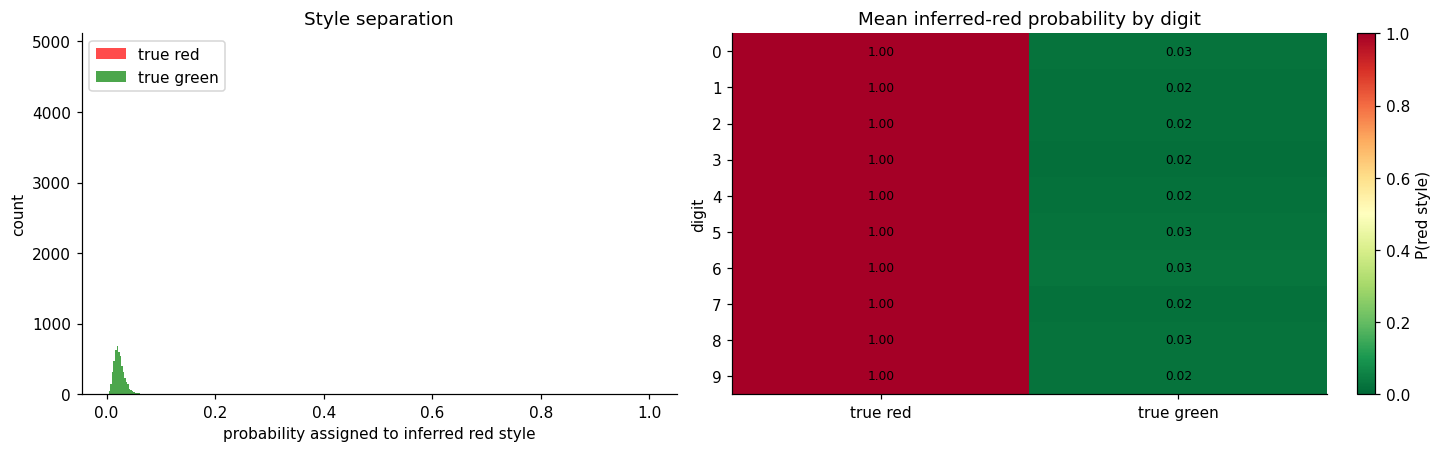

In [7]:
all_standardized = (
    (embedding_split["embeddings"] - mean) / std
).astype(np.float32)
style_chunks = []
batch_size = 1024
with torch.no_grad():
    for start_idx in range(0, len(all_standardized), batch_size):
        batch = torch.from_numpy(
            all_standardized[start_idx:start_idx + batch_size]
        ).to(device)
        _, z_bad = model.encode(batch)
        _, weights = model.decode_style(z_bad)
        style_chunks.append(weights.cpu().numpy())
all_style_weights = np.concatenate(style_chunks, axis=0)

mean_by_color = np.stack([
    all_style_weights[embedding_split["colors"] == color].mean(axis=0)
    for color in [0, 1]
])
color_to_style = {
    color: int(mean_by_color[color].argmax()) for color in [0, 1]
}
style_to_color = {style: color for color, style in color_to_style.items()}

print("Mean style probabilities by true color:")
print(f"red:   {mean_by_color[0]}")
print(f"green: {mean_by_color[1]}")
print(
    "Inferred mapping: "
    + ", ".join(
        f"style {style} -> {COLOR_NAMES[color]}"
        for style, color in sorted(style_to_color.items())
    )
)

red_style = color_to_style[0]
p_red = all_style_weights[:, red_style]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].hist(
    p_red[embedding_split["colors"] == 0],
    bins=30, alpha=0.7, label="true red", color="red",
)
axes[0].hist(
    p_red[embedding_split["colors"] == 1],
    bins=30, alpha=0.7, label="true green", color="green",
)
axes[0].set_xlabel("probability assigned to inferred red style")
axes[0].set_ylabel("count")
axes[0].set_title("Style separation")
axes[0].legend()

digit_color_means = np.zeros((10, 2))
for digit in range(10):
    for color in [0, 1]:
        mask = (
            (embedding_split["digits"] == digit)
            & (embedding_split["colors"] == color)
        )
        digit_color_means[digit, color] = p_red[mask].mean()

image = axes[1].imshow(
    digit_color_means, vmin=0, vmax=1, cmap="RdYlGn_r", aspect="auto"
)
axes[1].set_xticks([0, 1], ["true red", "true green"])
axes[1].set_yticks(range(10))
axes[1].set_ylabel("digit")
axes[1].set_title("Mean inferred-red probability by digit")
for digit in range(10):
    for color in [0, 1]:
        axes[1].text(
            color, digit, f"{digit_color_means[digit, color]:.2f}",
            ha="center", va="center", fontsize=8,
        )
fig.colorbar(image, ax=axes[1], label="P(red style)")
plt.show()

## 7. Forced-style interventions

A normal reconstruction uses the style probabilities predicted from
`z_bad`. To test causality, we replace those probabilities with one-hot
vectors:

$$
\pi = (1,0) \quad\text{or}\quad \pi=(0,1).
$$

The content embedding is held fixed. Only the selected transform changes.
If the factorization works, forced red and forced green should preserve
the digit instance while changing its color.

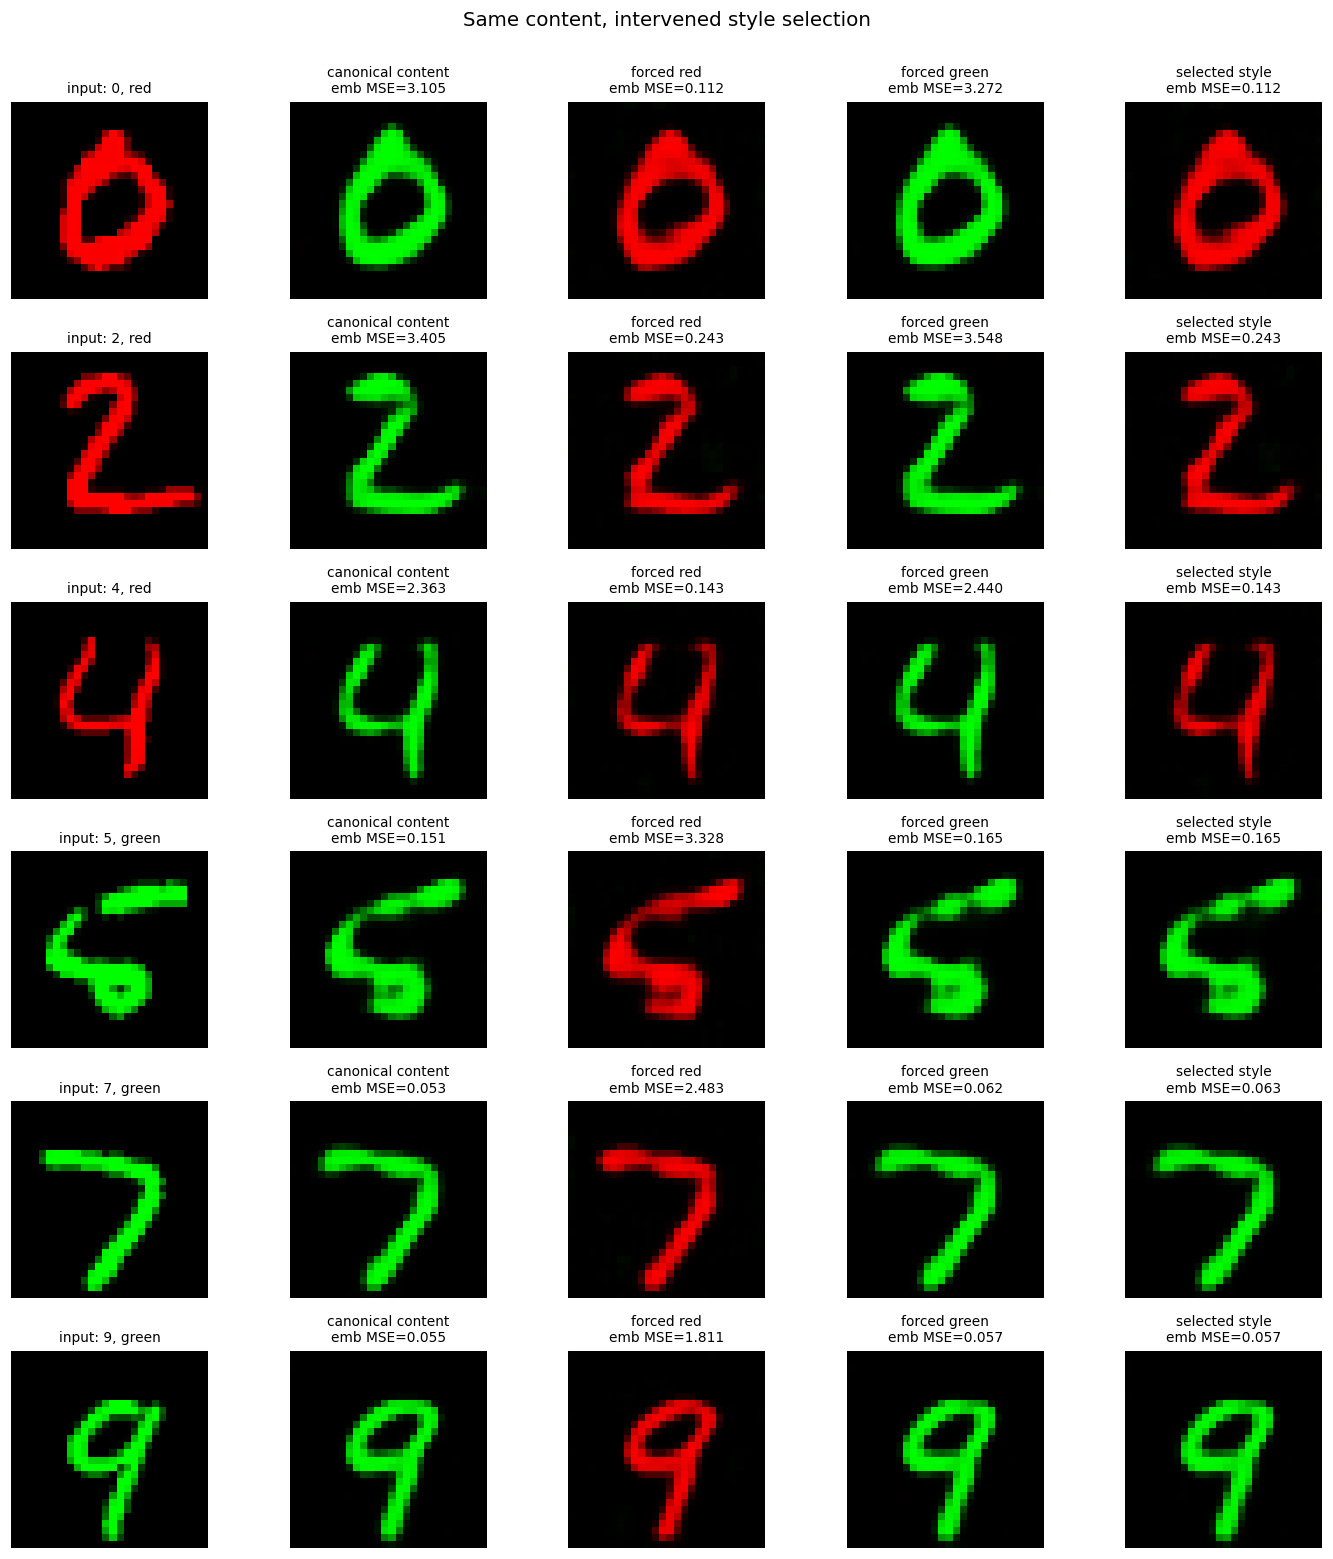

In [8]:
def decode_standardized(values):
    raw = values * std_t + mean_t
    return base_ae.decode(raw)

with torch.no_grad():
    content = outputs["good_reconstruction"]
    selected = outputs["reconstruction"]
    forced = {}
    for color in [0, 1]:
        weights = torch.zeros(
            len(indices), model.num_styles, device=device
        )
        weights[:, color_to_style[color]] = 1.0
        forced[color] = model.apply_style(content, weights)

    content_images = decode_standardized(content)
    selected_images = decode_standardized(selected)
    forced_images = {
        color: decode_standardized(values)
        for color, values in forced.items()
    }

columns = [
    ("input", None),
    ("canonical content", content_images),
    ("forced red", forced_images[0]),
    ("forced green", forced_images[1]),
    ("selected style", selected_images),
]
fig, axes = plt.subplots(
    len(indices), len(columns),
    figsize=(13, 2.35 * len(indices)),
    squeeze=False,
)
for row, index in enumerate(indices):
    true_color = int(embedding_split["colors"][index])
    digit = int(embedding_split["digits"][index])
    input_image = image_from_array(image_split["images"][index])
    axes[row, 0].imshow(input_image)
    axes[row, 0].set_title(
        f"input: {digit}, {COLOR_NAMES[true_color]}", fontsize=9
    )

    for col, (title, images) in enumerate(columns[1:], start=1):
        axes[row, col].imshow(image_from_tensor(images[row]))
        if title == "canonical content":
            mse = F.mse_loss(content[row], x[row]).item()
        elif title == "selected style":
            mse = F.mse_loss(selected[row], x[row]).item()
        elif title == "forced red":
            mse = F.mse_loss(forced[0][row], x[row]).item()
        else:
            mse = F.mse_loss(forced[1][row], x[row]).item()
        axes[row, col].set_title(f"{title}\nemb MSE={mse:.3f}", fontsize=9)

    for axis in axes[row]:
        axis.axis("off")
fig.suptitle(
    "Same content, intervened style selection",
    fontsize=13, y=1.002,
)
fig.tight_layout()
plt.show()

### Interpolate between styles

The decoder uses a soft mixture, so we can continuously vary

$$
\pi_{\mathrm{red}}=\alpha,\qquad
\pi_{\mathrm{green}}=1-\alpha.
$$

This is not an independent `z_bad` reconstruction. Every image below is
produced from exactly the same canonical content vector.

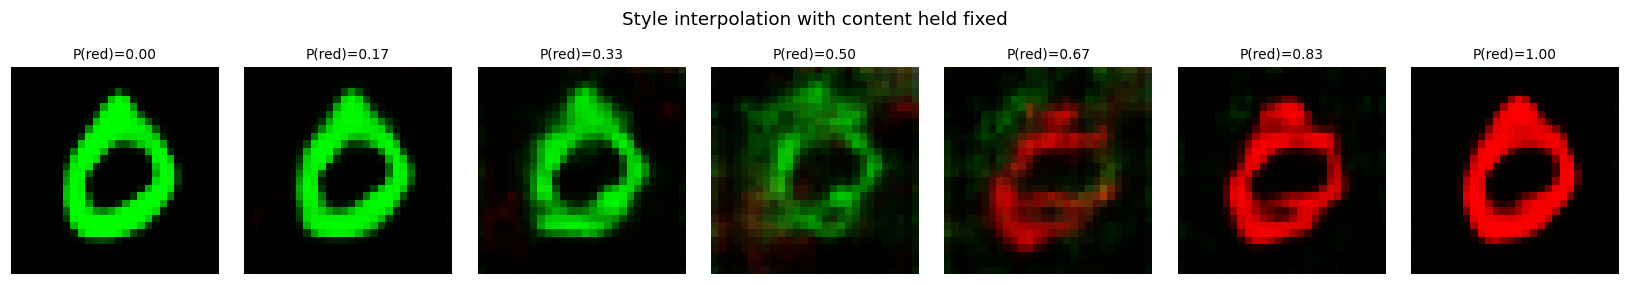

In [9]:
row = 0
alphas = np.linspace(0.0, 1.0, 7)
interpolated = []
with torch.no_grad():
    for alpha in alphas:
        weights = torch.zeros(1, model.num_styles, device=device)
        weights[0, color_to_style[0]] = float(alpha)
        weights[0, color_to_style[1]] = float(1.0 - alpha)
        styled = model.apply_style(content[row:row + 1], weights)
        interpolated.append(decode_standardized(styled)[0])

fig, axes = plt.subplots(1, len(alphas), figsize=(15, 2.5))
for axis, alpha, image in zip(axes, alphas, interpolated):
    axis.imshow(image_from_tensor(image))
    axis.set_title(f"P(red)={alpha:.2f}", fontsize=9)
    axis.axis("off")
fig.suptitle("Style interpolation with content held fixed", y=1.02)
plt.tight_layout()
plt.show()

## 8. Inspect the learned transform bank

Each style owns a residual matrix $A_k$ and bias $b_k$. The effective
affine map is

$$
T_k(c)=(I+A_k)c+b_k.
$$

The matrices are not directly interpretable as RGB operations because
they act in the frozen base-AE embedding space. Still, their norms,
differences, and singular values reveal whether the two style operators
actually diverged from one another and from identity.

green style=0: ||A||_F=1.899, ||b||_2=0.363, singular range=[0.611, 1.498]
red   style=1: ||A||_F=10.281, ||b||_2=0.683, singular range=[0.030, 2.111]
transform separation: ||A_red-A_green||_F=10.628


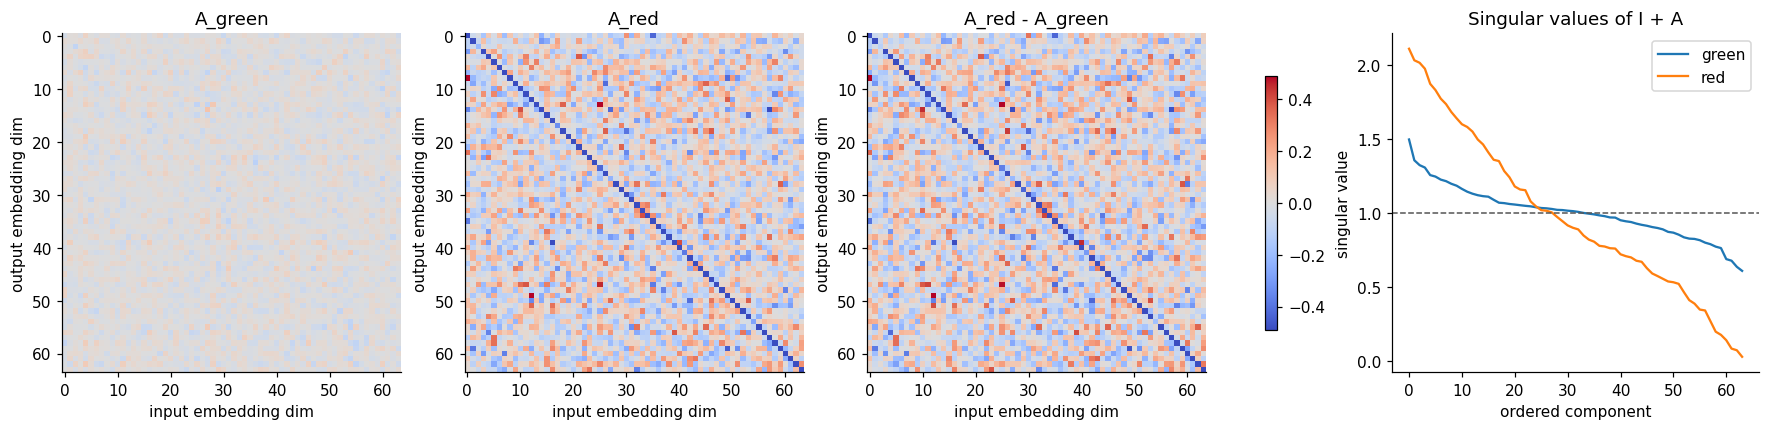

In [10]:
matrices = model.style_residual_matrices.detach().cpu().numpy()
biases = model.style_residual_biases.detach().cpu().numpy()
identity = np.eye(model.input_dim)

ordered_styles = [color_to_style[1], color_to_style[0]]  # green, red
ordered_names = ["green", "red"]
for name, style in zip(ordered_names, ordered_styles):
    effective = identity + matrices[style]
    singular = np.linalg.svd(effective, compute_uv=False)
    print(
        f"{name:5s} style={style}: "
        f"||A||_F={np.linalg.norm(matrices[style]):.3f}, "
        f"||b||_2={np.linalg.norm(biases[style]):.3f}, "
        f"singular range=[{singular.min():.3f}, {singular.max():.3f}]"
    )
print(
    "transform separation: "
    f"||A_red-A_green||_F="
    f"{np.linalg.norm(matrices[ordered_styles[1]] - matrices[ordered_styles[0]]):.3f}"
)

green_matrix = matrices[ordered_styles[0]]
red_matrix = matrices[ordered_styles[1]]
difference = red_matrix - green_matrix
vmax = np.percentile(np.abs(np.concatenate([
    green_matrix.ravel(), red_matrix.ravel(), difference.ravel()
])), 99)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), constrained_layout=True)
for axis, values, title in [
    (axes[0], green_matrix, "A_green"),
    (axes[1], red_matrix, "A_red"),
    (axes[2], difference, "A_red - A_green"),
]:
    image = axis.imshow(values, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axis.set_title(title)
    axis.set_xlabel("input embedding dim")
    axis.set_ylabel("output embedding dim")
fig.colorbar(image, ax=axes[:3], shrink=0.75)

for name, style in zip(ordered_names, ordered_styles):
    singular = np.linalg.svd(identity + matrices[style], compute_uv=False)
    axes[3].plot(singular, label=name)
axes[3].axhline(1.0, color="#555555", linestyle="--", linewidth=1)
axes[3].set_title("Singular values of I + A")
axes[3].set_xlabel("ordered component")
axes[3].set_ylabel("singular value")
axes[3].legend()
plt.show()

## 9. Gradient-flow audit

The next cell uses autograd to measure which parameter groups receive
gradients from three losses:

- full reconstruction;
- canonical good reconstruction;
- paired red/green invariance.

Expected pattern:

- reconstruction reaches both branches and the transform bank;
- canonicalization reaches the shared trunk, good encoder, and good
  decoder;
- pair invariance reaches the shared trunk and good encoder;
- the color heads receive no gradients because they are not part of
  these objectives.

This is a direct implementation check rather than an inference from the
loss equations.

parameter group        reconstruction        canonical  pair invariance
-------------------------------------------------------------------------
shared encoder              9.371e-02        3.118e-01        1.024e-01
good encoder                1.001e-01        3.604e-01        8.133e-02
bad encoder                 3.001e-02        0.000e+00        0.000e+00
good decoder                3.083e-01        1.082e+00        0.000e+00
style selector              2.902e-02        0.000e+00        0.000e+00
style transforms            3.014e-01        0.000e+00        0.000e+00
color heads                 0.000e+00        0.000e+00        0.000e+00


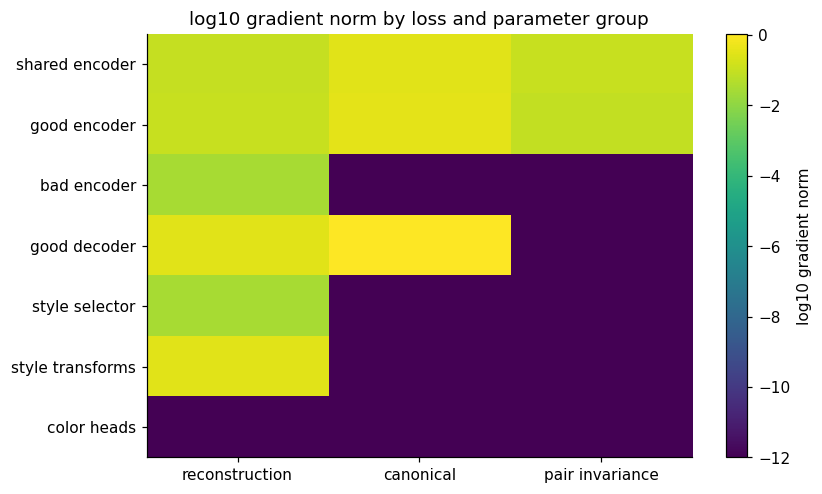

In [11]:
sample_images = image_split["images"][indices]
canonical_np = canonical_good.make_canonical_good_embeddings(
    sample_images,
    base_ae,
    device,
    mean=mean,
    std=std,
    batch_size=len(indices),
    target=args["canonical_good_target"],
)
red_np, green_np = scheduled.make_paired_embeddings(
    sample_images,
    base_ae,
    device,
    mean=mean,
    std=std,
    batch_size=len(indices),
)
canonical_t = torch.from_numpy(canonical_np).to(device)
red_t = torch.from_numpy(red_np).to(device)
green_t = torch.from_numpy(green_np).to(device)

gradient_groups = {
    "shared encoder": list(model.encoder.parameters()),
    "good encoder": list(model.good_encoder.parameters()),
    "bad encoder": list(model.bad_encoder.parameters()),
    "good decoder": list(model.good_decoder.parameters()),
    "style selector": list(model.style_selector.parameters()),
    "style transforms": [
        model.style_residual_matrices,
        model.style_residual_biases,
    ],
    "color heads": (
        list(model.good_color_head.parameters())
        + list(model.bad_color_head.parameters())
    ),
}

def group_gradient_norm(parameters):
    squared = 0.0
    for parameter in parameters:
        if parameter.grad is not None:
            squared += parameter.grad.detach().pow(2).sum().item()
    return squared ** 0.5

def audit_loss(loss_name):
    model.zero_grad(set_to_none=True)
    if loss_name == "reconstruction":
        z_good, z_bad = model.encode(x)
        decoded = model.decode(
            z_good,
            z_bad,
            good_grad_scale=args["good_full_recon_grad_scale"],
            style_enabled=True,
        )
        loss = F.mse_loss(decoded["reconstruction"], x)
    elif loss_name == "canonical":
        z_good, _ = model.encode(x)
        loss = F.mse_loss(model.decode_good(z_good), canonical_t)
    elif loss_name == "pair invariance":
        loss, _, _, _ = scheduled.pair_losses(
            model, red_t, green_t, args["pair_variance_eps"]
        )
    else:
        raise ValueError(loss_name)
    loss.backward()
    return {
        name: group_gradient_norm(parameters)
        for name, parameters in gradient_groups.items()
    }

loss_names = ["reconstruction", "canonical", "pair invariance"]
audit = {name: audit_loss(name) for name in loss_names}

print(f"{'parameter group':20s} " + " ".join(
    f"{name:>16s}" for name in loss_names
))
print("-" * 73)
for group in gradient_groups:
    print(
        f"{group:20s} "
        + " ".join(
            f"{audit[loss][group]:16.3e}" for loss in loss_names
        )
    )

values = np.array([
    [audit[loss][group] for loss in loss_names]
    for group in gradient_groups
])
log_values = np.log10(values + 1e-12)
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(log_values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(loss_names)), loss_names)
ax.set_yticks(range(len(gradient_groups)), list(gradient_groups))
ax.set_title("log10 gradient norm by loss and parameter group")
fig.colorbar(image, ax=ax, label="log10 gradient norm")
plt.show()

model.zero_grad(set_to_none=True)

## 10. Probe the representations actually used by the decoder

For the style pathway, three representations answer different questions:

1. **Raw `z_bad`:** what information could be stored in the four
   continuous latent values?
2. **Style logits:** what survives the learned selector?
3. **Style probabilities:** what the decoder actually consumes.

A factorized decoder can be successful even if raw `z_bad` retains some
linearly decodable digit variation, provided that this variation is
discarded before the final style probabilities.

The plot uses balanced-accuracy probes trained on balanced data. Chance
is 0.10 for digit, 0.50 for digit group, and 0.50 for color.

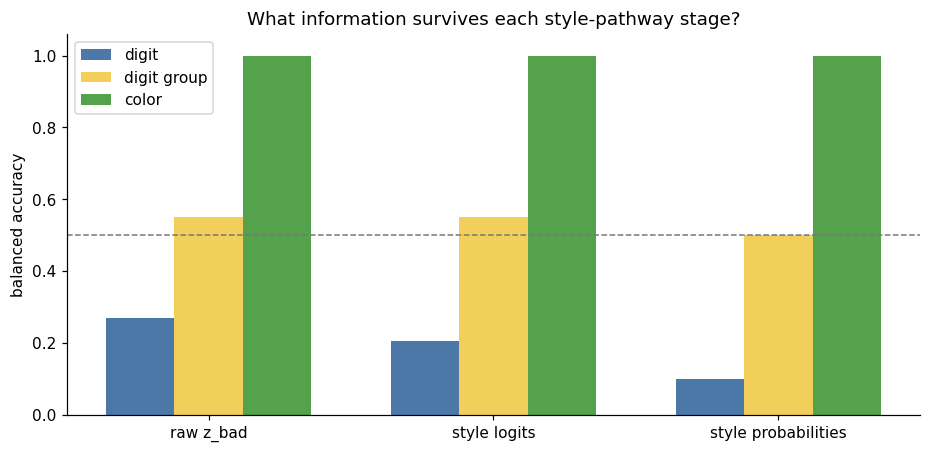

representation              digit      group      color
z_bad                      0.2711     0.5511     1.0000
style_logits               0.2074     0.5508     1.0000
style_probabilities        0.1000     0.5000     1.0000


In [12]:
style_probe_path = (
    PROJECT_ROOT
    / "outputs"
    / "factorized_style_probes"
    / f"{RESULT_TAG}_balanced_probe_train"
    / "style_representation_probe_results.json"
)

if style_probe_path.exists():
    probe = json.loads(style_probe_path.read_text())
    balanced = probe["results"]["test_balanced"]["probe_accuracy"]
    representations = ["z_bad", "style_logits", "style_probabilities"]
    labels = ["digits", "digit_groups", "colors"]
    label_names = ["digit", "digit group", "color"]
    values = np.array([
        [balanced[rep][label]["balanced_accuracy"] for label in labels]
        for rep in representations
    ])

    x_pos = np.arange(len(representations))
    width = 0.24
    fig, ax = plt.subplots(figsize=(10, 4.5))
    colors = ["#4c78a8", "#f2cf5b", "#54a24b"]
    for idx, (label_name, color) in enumerate(zip(label_names, colors)):
        ax.bar(
            x_pos + (idx - 1) * width,
            values[:, idx],
            width,
            label=label_name,
            color=color,
        )
    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1)
    ax.set_xticks(
        x_pos,
        ["raw z_bad", "style logits", "style probabilities"],
    )
    ax.set_ylim(0, 1.06)
    ax.set_ylabel("balanced accuracy")
    ax.set_title("What information survives each style-pathway stage?")
    ax.legend()
    plt.show()

    print(f"{'representation':22s} {'digit':>10s} {'group':>10s} {'color':>10s}")
    for rep, row_values in zip(representations, values):
        print(
            f"{rep:22s} "
            + " ".join(f"{value:10.4f}" for value in row_values)
        )
else:
    print(f"Probe output not found: {style_probe_path}")
    print("Run scripts/probe/probe_factorized_style_representations.py first.")

## 11. Counterfactual evidence

The strongest test is not ordinary reconstruction. It is an intervention:

- keep the source content fixed;
- force the inferred red or green style;
- compare against the true counterfactual embedding of the same digit
  instance recolored red or green.

A successful result requires all of the following:

- the automatically inferred style mapping is unambiguous;
- the correct-color target is closer than the wrong-color target;
- digit identity survives either forced style;
- forced color is correctly recoverable;
- reconstructions from red and green source versions agree after forcing
  the same target style.

In [13]:
counterfactual_path = (
    PROJECT_ROOT
    / "outputs"
    / "factorized_counterfactual_style_eval"
    / RESULT_TAG
    / "counterfactual_style_results.json"
)

if counterfactual_path.exists():
    result = json.loads(counterfactual_path.read_text())
    balanced = result["results"]["test_balanced"]
    mapping = balanced["style_mapping"]
    conditions = balanced["conditions"]

    print(
        "Automatic style mapping accuracy: "
        f"{mapping['selected_mapping_accuracy']:.4f}"
    )
    print(
        "Content red/green MSE: "
        f"{balanced['content_red_green_mse']:.6f}"
    )

    header = (
        "| condition | target MSE | wrong target MSE | "
        "target preference | digit bal. acc. | color bal. acc. |\n"
        "|---|---:|---:|---:|---:|---:|\n"
    )
    rows = []
    for name, metrics in conditions.items():
        rows.append(
            f"| {name.replace('_', ' ')} "
            f"| {metrics['embedding_mse']:.4f} "
            f"| {metrics['wrong_color_embedding_mse']:.4f} "
            f"| {metrics['correct_target_preference_rate']:.4f} "
            f"| {metrics['digit_probe']['balanced_accuracy']:.4f} "
            f"| {metrics['forced_color_probe']['balanced_accuracy']:.4f} |"
        )
    display(Markdown(header + "\n".join(rows)))

    consistency = balanced["cross_source_consistency"]
    print("Cross-source consistency:")
    for key, value in consistency.items():
        if isinstance(value, (int, float)):
            print(f"  {key:42s} {value:.6f}")
else:
    print(f"Counterfactual output not found: {counterfactual_path}")
    print("Run scripts/probe/evaluate_factorized_counterfactual_styles.py first.")

Automatic style mapping accuracy: 1.0000
Content red/green MSE: 0.011055


| condition | target MSE | wrong target MSE | target preference | digit bal. acc. | color bal. acc. |
|---|---:|---:|---:|---:|---:|
| source red force red | 0.1567 | 2.2012 | 1.0000 | 0.8780 | 1.0000 |
| source red force green | 0.1294 | 2.7989 | 1.0000 | 0.8703 | 1.0000 |
| source green force red | 0.1640 | 2.1755 | 1.0000 | 0.8763 | 1.0000 |
| source green force green | 0.1244 | 2.7672 | 1.0000 | 0.8687 | 1.0000 |

Cross-source consistency:


## 12. Interpretation and limits

### What the current result supports

- `z_good` is the content pathway: its balanced-test digit probe is high
  and its global color probe is close to chance.
- The learned selector discovers the two colors even without direct
  style-label cross-entropy.
- Style probabilities are a strong information bottleneck: color remains
  perfect while digit and digit-group probes fall to chance.
- Forced-style interventions preserve digit identity and recover the
  paired target color, so the style code is causally used by the decoder.
- Reconstruction is substantially better than with the additive
  canonical residual architecture.

### What should not be claimed

- Raw `z_bad` is not mathematically guaranteed to contain only color.
  It still has four continuous dimensions and retains some decodable
  variation.
- The experiment is not fully unsupervised. It uses a two-style
  architectural prior, canonical green targets, and explicitly
  constructed red/green pairs.
- The learned matrices act in base-AE embedding space. Calling them
  literal RGB recoloring operators would be too strong.
- A shared encoder trunk remains a coupling point between content and
  style gradients.

### Useful modifications

- Change `RUN_NAME` to compare supervised and no-label factorized runs.
- Change `CHECKPOINT_NAME` to `phase1_end` or `phase2_end` to inspect how
  routing develops through the schedule.
- Change `SPLIT` to `test_reversed` to expose reliance on the training
  digit-color correlation.
- Repeat the entire notebook across multiple seeds before treating the
  numerical result as robust.

The central architectural insight is that factorization changes the
question from *"can `z_bad` reconstruct a residual image?"* to
*"which reusable transformation should be applied to this content?"*
That restriction is what makes the decoder-facing style representation
substantially cleaner.